# Demo 2: Controller runtime analysis

Compare the CSVs produced by `demo2.py --benchmark-agent`. The stacked bars separate **METS-R**, **CARLA**, **Scenic**, and the **PCLA agent**. Only completed, valid runs contribute to the comparisons; failures remain visible in the coverage report.

**Run all cells** in a Python kernel with `pandas`, `numpy`, and `matplotlib`. No simulator connection is needed. By default, the notebook reads the latest session under the normal benchmark output directory. Set `SESSION` below to pin an experiment, or change `BENCHMARK_ROOT` for a custom export location.

The saved outputs are a snapshot of the session named below. Rerun the notebook after a benchmark finishes to refresh them.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator
from IPython.display import display, Markdown

# Works when launched from the repository root or tutorials/dashboard_demos.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "tutorials/dashboard_demos/demo2.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the METS-R_HPC checkout.")

BENCHMARK_ROOT = PROJECT_ROOT / "scenic_exp/data_logs/CARLA_06/constant_flow/benchmarks"
SESSION = None                   # None = latest; or "20260913_174359_1789335839086850722"
AGENTS = None                    # None = all; or ["lmdrive_llama", "lav_fast", "minddrive_05b"]
COHORT_FILTER = {}               # Optional: {"town": "Town06", "requested_seconds": 10}
EXCLUDE_RUNS = []                # Example: [1] to inspect later repetitions separately
MATCH_REPETITIONS = True         # Compare the same (run, seed) pairs across controllers
CONTROLLERS_PER_FIGURE = 20       # Paginate long controller lists; each page has its own cost scale
PCLA_DETAIL_COUNT = 12           # Show initialization/action detail for the slowest controllers
SAVE_OUTPUTS = True              # PNG/PDF figures, analysis tables, and source manifest

COSTS = {
    "metsr_s": ("METS-R", "#277DA8"),
    "carla_s": ("CARLA", "#279B86"),
    "scenic_s": ("Scenic", "#8B78AF"),
    "pcla_agent_s": ("PCLA agent", "#E58B36"),
}
COST_COLUMNS = list(COSTS)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "font.family": "DejaVu Sans",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#BCC6CE", "text.color": "#203747",
    "axes.labelcolor": "#203747", "xtick.color": "#516575", "ytick.color": "#203747",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
pd.set_option("display.max_colwidth", 130)


## 1. Select a benchmark session

Sessions are kept separate: combining an old failed sweep with a later retry can mix code versions, cache state, or scenario settings. The loader reads only controller CSVs immediately inside the selected session directory, retaining filenames for traceability.


In [2]:
sessions = sorted(p for p in BENCHMARK_ROOT.glob("*") if p.is_dir() and any(p.glob("*.csv")))
if not sessions:
    raise FileNotFoundError(f"No benchmark CSVs found under {BENCHMARK_ROOT}")
if SESSION is None:
    session_dir = sessions[-1]
else:
    requested = Path(SESSION).expanduser()
    session_dir = requested if requested.is_absolute() else BENCHMARK_ROOT / requested
csv_paths = sorted(session_dir.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No controller CSVs found in {session_dir}")

required = {"agent", "run", "seed", "status", "scenario", "town", "num_commuters",
            "requested_seconds", "timestep_s", "simulation_steps", "simulation_seconds",
            "loop_wall_s", *COST_COLUMNS}
frames, load_issues = [], []
for path in csv_paths:
    try:
        frame = pd.read_csv(path)
        missing = required - set(frame.columns)
        if missing:
            raise ValueError("missing columns: " + ", ".join(sorted(missing)))
        if frame.empty:
            raise ValueError("CSV has no data rows")
        frame["source_csv"] = path.name
        frames.append(frame)
    except (OSError, ValueError, pd.errors.ParserError) as exc:
        load_issues.append({"source_csv": path.name, "problem": str(exc)})
if not frames:
    raise ValueError(f"No readable benchmark rows: {load_issues}")
raw_runs = pd.concat(frames, ignore_index=True, sort=False)
runs = raw_runs.copy()
for name in ("agent", "status", "town", "scenario"):
    runs[name] = runs[name].fillna("").astype(str).str.strip()
runs["status"] = runs["status"].str.lower()
numeric_columns = ["run", "seed", "num_commuters", "requested_seconds", "timestep_s",
                   "simulation_steps", "simulation_seconds", "loop_wall_s", *COST_COLUMNS,
                   "pcla_setup_s", "pcla_action_s", "pcla_action_calls",
                   "compile_s", "scene_generation_s", "simulator_setup_s", "simulate_call_s"]
for name in numeric_columns:
    if name not in runs:
        runs[name] = np.nan       # Optional fields from older CSV versions
    runs[name] = pd.to_numeric(runs[name], errors="coerce")
if AGENTS is not None:
    unknown = set(AGENTS) - set(runs.agent)
    if unknown:
        raise ValueError(f"Controllers absent from this session: {sorted(unknown)}")
    runs = runs[runs.agent.isin(AGENTS)].copy()
for name, value in COHORT_FILTER.items():
    if name not in runs:
        raise KeyError(f"Unknown cohort field: {name}")
    runs = runs[runs[name].eq(value)].copy()
if runs.empty:
    raise ValueError("No rows match AGENTS / COHORT_FILTER.")

output_dir = PROJECT_ROOT / "output/demo2_analysis" / session_dir.name
print(f"Session: {session_dir.name}")
print(f"Source: {session_dir}")
print(f"Loaded {len(raw_runs)} rows from {len(frames)} controller CSVs.")
if load_issues:
    display(Markdown("**CSV loading problems - these files are excluded:**"))
    display(pd.DataFrame(load_issues))


Session: 20260913_174359_1789335839086850722
Source: /mnt/c/Users/ALei/Documents/GitHub/METS-R_HPC/scenic_exp/data_logs/CARLA_06/constant_flow/benchmarks/20260913_174359_1789335839086850722
Loaded 175 rows from 59 controller CSVs.


## 2. Check coverage and comparability

Failed, skipped, interrupted, and still-running rows are **not zero-cost controllers**. They are listed separately and excluded from timing plots. Completed rows must have finite, nonnegative costs, positive simulated duration, and a consistent four-part runtime total.

By default, plotted controllers use the intersection of their completed **(run number, seed)** pairs. This keeps the repetition schedule matched when a controller completed only part of a sweep. Controllers with no valid completed runs remain outside the comparison. `EXCLUDE_RUNS=[1]` can explore later repetitions, but does not remove initialization from those repetitions.


In [3]:
settings = ["scenario", "town", "num_commuters", "requested_seconds", "timestep_s"]
cohorts = runs[settings].drop_duplicates()
if len(cohorts) != 1:
    display(cohorts)
    raise ValueError("Mixed scenario settings. Select one group with COHORT_FILTER before comparing controllers.")
display(cohorts.assign(scenario=cohorts.scenario.str.replace("\\", "/", regex=False).str.rsplit("/", n=1).str[-1]))

coverage = pd.crosstab(runs.agent, runs.status)
for status in ["finished", "failed", "interrupted", "skipped", "running"]:
    if status not in coverage:
        coverage[status] = 0
display(runs.status.value_counts().rename_axis("Status").to_frame("CSV rows"))
unsuccessful = runs[~runs.status.eq("finished")]
if not unsuccessful.empty:
    display(Markdown("**Rows excluded because they did not finish:**"))
    columns = ["agent", "run", "status", "source_csv"] + (["error"] if "error" in runs else [])
    display(unsuccessful[columns].fillna(""))

completed = runs[runs.status.eq("finished")].copy()
checked_columns = [*COST_COLUMNS, "loop_wall_s", "simulation_seconds", "simulation_steps",
                   "requested_seconds", "timestep_s", "run", "seed"]
finite = pd.Series(np.isfinite(completed[checked_columns].to_numpy(dtype=float)).all(axis=1), index=completed.index)
nonnegative = completed[[*COST_COLUMNS, "loop_wall_s"]].ge(0).all(axis=1)
positive = completed[["loop_wall_s", "simulation_seconds", "simulation_steps", "timestep_s", "run"]].gt(0).all(axis=1)
balanced = np.isclose(completed[COST_COLUMNS].sum(axis=1), completed.loop_wall_s, rtol=1e-6, atol=1e-6)
consistent_duration = np.isclose(completed.simulation_steps * completed.timestep_s,
                                 completed.simulation_seconds, rtol=1e-6, atol=1e-6)
valid_mask = finite & nonnegative & positive & balanced & consistent_duration & completed.agent.ne("")
invalid_completed = completed.loc[~valid_mask].copy()
if not invalid_completed.empty:
    display(Markdown("**Completed rows excluded by timing validation (missing, negative, or inconsistent data):**"))
    display(invalid_completed[["agent", "run", "source_csv", "loop_wall_s", *COST_COLUMNS]])
valid = completed.loc[valid_mask & ~completed.run.isin(EXCLUDE_RUNS)].copy()
if valid.empty:
    raise ValueError("No valid completed runs remain to plot. Check the reports above.")
if valid.duplicated(["agent", "run", "seed"]).any():
    raise ValueError("Duplicate completed (agent, run, seed) rows. Review the source CSVs before aggregation.")

before_matching = len(valid)
if MATCH_REPETITIONS:
    repetition_sets = [set(zip(group.run, group.seed)) for _, group in valid.groupby("agent")]
    common_pairs = set.intersection(*repetition_sets)
    if not common_pairs:
        raise ValueError("No completed repetitions are shared across controllers. Select AGENTS or set MATCH_REPETITIONS=False.")
    valid = valid[[pair in common_pairs for pair in zip(valid.run, valid.seed)]].copy()
    print("Matched (run, seed) pairs:", sorted((int(r), int(s)) for r, s in common_pairs))
else:
    print("Unmatched repetitions enabled; inspect coverage before interpreting rankings.")
coverage["plotted_runs"] = valid.groupby("agent").size().reindex(coverage.index, fill_value=0)
print(f"Plotting {len(valid)} completed runs across {valid.agent.nunique()} / {runs.agent.nunique()} controllers.")
print(f"Removed {before_matching - len(valid)} otherwise valid rows to match repetitions.")
coverage_changes = coverage[(coverage.plotted_runs != coverage.finished) | coverage.plotted_runs.eq(0)]
if not coverage_changes.empty:
    display(coverage_changes[["finished", "failed", "interrupted", "skipped", "running", "plotted_runs"]])
if valid.simulation_seconds.nunique() > 1:
    print("Completed durations differ. Normalized costs account for duration, but initialization is amortized differently.")


,scenario,town,num_commuters,requested_seconds,timestep_s
0,constant_flow_n_bubble_n_attack.scenic,Town06,5,10,0.1


,CSV rows
Status,
finished,174
failed,1


**Rows excluded because they did not finish:**

,agent,run,status,source_csv,error
81,orion_base,1,failed,orion_base.csv,Worker exited with code -9; see orion_base.log


Matched (run, seed) pairs: [(1, 33), (2, 34), (3, 35)]
Plotting 174 completed runs across 58 / 59 controllers.
Removed 0 otherwise valid rows to match repetitions.


status,finished,failed,interrupted,skipped,running,plotted_runs
agent,,,,,,
orion_base,0,1,0,0,0,0


## 3. Aggregate runtime without double counting

The four exclusive components satisfy:

`loop_wall_s = metsr_s + carla_s + scenic_s + pcla_agent_s`

The main chart uses **wall seconds per simulated second**: sum of each component divided by the total simulated seconds for that controller. The adjacent chart shows **percentage of loop time**. Pooled throughput is total simulated steps / total loop wall time; the real-time factor is total simulated seconds / total loop wall time.

These are client-observed elapsed times, including blocking waits. They are not server CPU usage or GPU kernel timings. Initialization inside the loop remains included. Compilation, scene generation, simulator setup, and teardown outside the loop are excluded from the four-part stack. `pcla_setup_s` and `pcla_action_s` are inclusive detail measurements and must **not** be added to the four components. See [the benchmark timing definitions](demo2_benchmark.md#timing-definitions).


In [4]:
groups = valid.groupby("agent", sort=True)
summary = groups.agg(
    n_runs=("run", "size"), loop_mean_s=("loop_wall_s", "mean"), loop_std_s=("loop_wall_s", "std"),
    total_loop_s=("loop_wall_s", "sum"), total_simulated_s=("simulation_seconds", "sum"),
    total_steps=("simulation_steps", "sum"),
    pcla_setup_mean_s=("pcla_setup_s", "mean"), pcla_action_mean_s=("pcla_action_s", "mean"),
)
mean_costs = groups[COST_COLUMNS].mean()
summed_costs = groups[COST_COLUMNS].sum()
normalized_costs = summed_costs.div(summary.total_simulated_s, axis=0)
shares = summed_costs.div(summary.total_loop_s, axis=0) * 100
summary["wall_s_per_sim_s"] = summary.total_loop_s / summary.total_simulated_s
summary["steps_per_wall_s"] = summary.total_steps / summary.total_loop_s
summary["realtime_factor"] = summary.total_simulated_s / summary.total_loop_s
summary["normal_cost_std"] = valid.assign(
    normalized_loop=valid.loop_wall_s / valid.simulation_seconds
).groupby("agent").normalized_loop.std()
summary["pcla_action_mean_ms"] = (
    groups.pcla_action_s.sum(min_count=1) / groups.pcla_action_calls.sum(min_count=1).replace(0, np.nan) * 1000
)
summary["dominant_component"] = shares.idxmax(axis=1).map({key: label for key, (label, _) in COSTS.items()})
for name in COST_COLUMNS:
    summary[f"{name}_mean"] = mean_costs[name]
    summary[f"{name}_per_sim_s"] = normalized_costs[name]
    summary[f"{name}_pct"] = shares[name]
summary = summary.sort_values("wall_s_per_sim_s")
assert np.allclose(normalized_costs.sum(axis=1), summary.wall_s_per_sim_s.reindex(normalized_costs.index))
assert np.allclose(shares.sum(axis=1), 100)
print("Cost totals reconcile for every plotted controller.")
summary_columns = ["n_runs", "loop_mean_s", "wall_s_per_sim_s", "realtime_factor", "steps_per_wall_s", "dominant_component"]
display(summary[summary_columns].round(3))


Cost totals reconcile for every plotted controller.


,n_runs,loop_mean_s,wall_s_per_sim_s,realtime_factor,steps_per_wall_s,dominant_component
agent,,,,,,
lbc_lb,3,6.201,0.620,1.613,16.127,PCLA agent
carl_roach_3,3,6.311,0.631,1.585,15.845,PCLA agent
carl_roach_4,3,6.349,0.635,1.575,15.750,PCLA agent
carl_roach_2,3,6.375,0.637,1.569,15.687,PCLA agent
lbc_nc,3,6.537,0.654,1.530,15.297,Scenic
carl_roach_1,3,6.556,0.656,1.525,15.253,PCLA agent
carl_roach_0,3,6.673,0.667,1.499,14.987,PCLA agent
carl_carl_1,3,6.792,0.679,1.472,14.724,PCLA agent
neat_aimbev,3,6.891,0.689,1.451,14.512,PCLA agent


## 4. Stacked runtime comparison

Controllers are ordered from **lowest to highest cost per simulated second**. The left bar-end label is the total cost; a value below 1 means faster than real time for the measured loop. Black whiskers show one sample standard deviation of per-run normalized cost (lower end clipped at zero), not confidence intervals. They are absent for a single repetition.

The right panel always spans 0-100%; labels are shown only for shares of at least 10%. Long lists are paginated. **Each page has its own left-axis scale** so faster controllers remain readable; compare the numeric totals across pages. All pages use the same colors and right-axis scale.


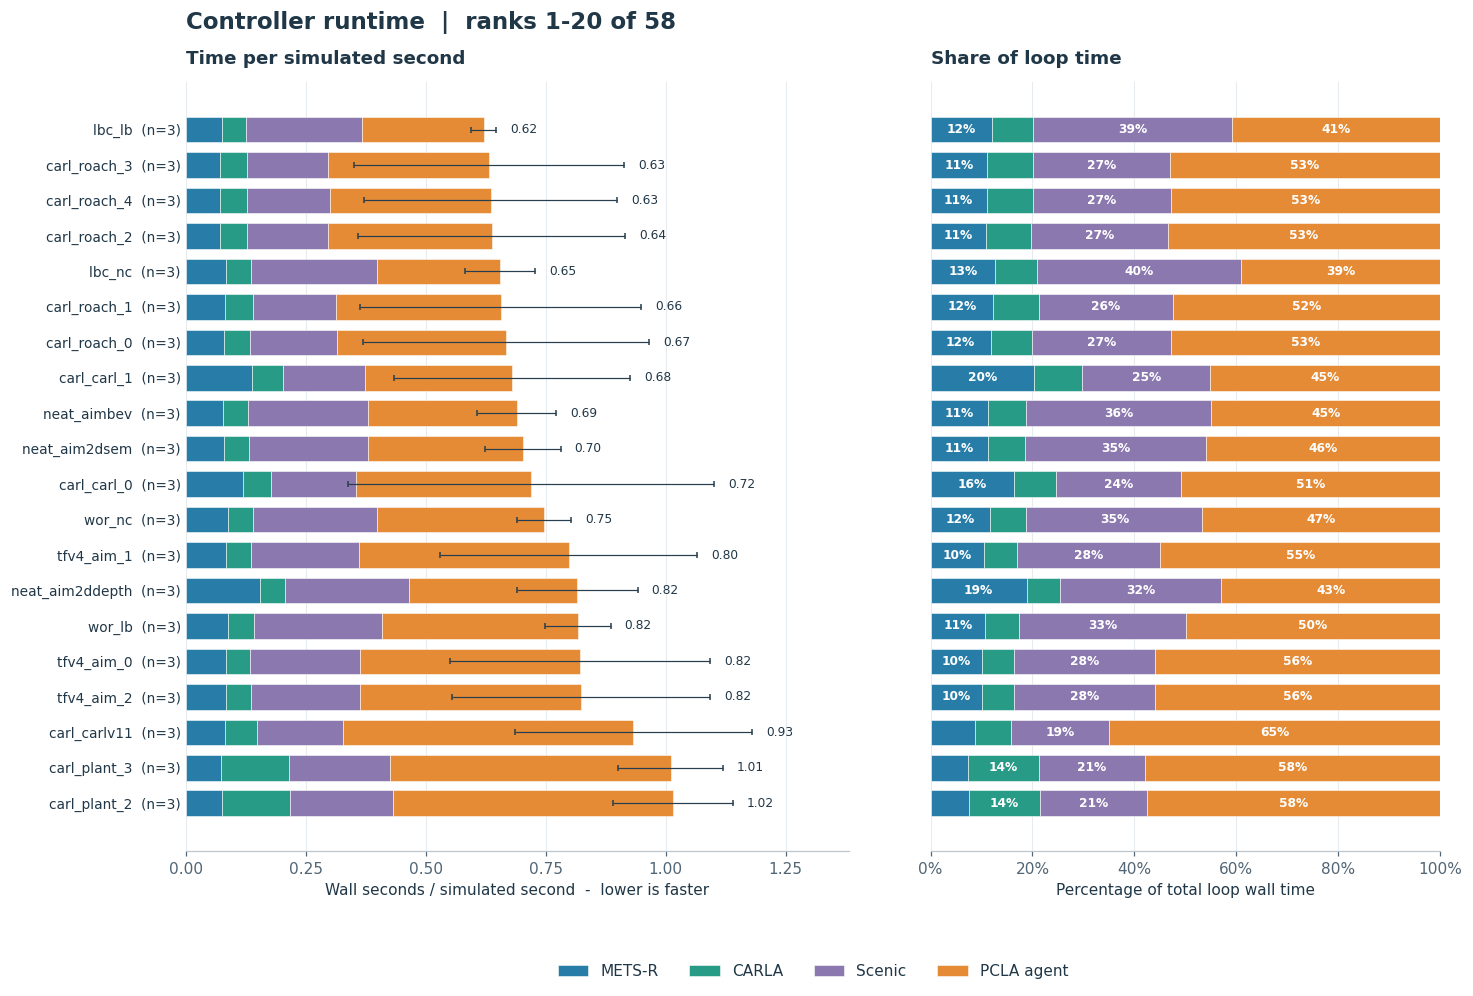

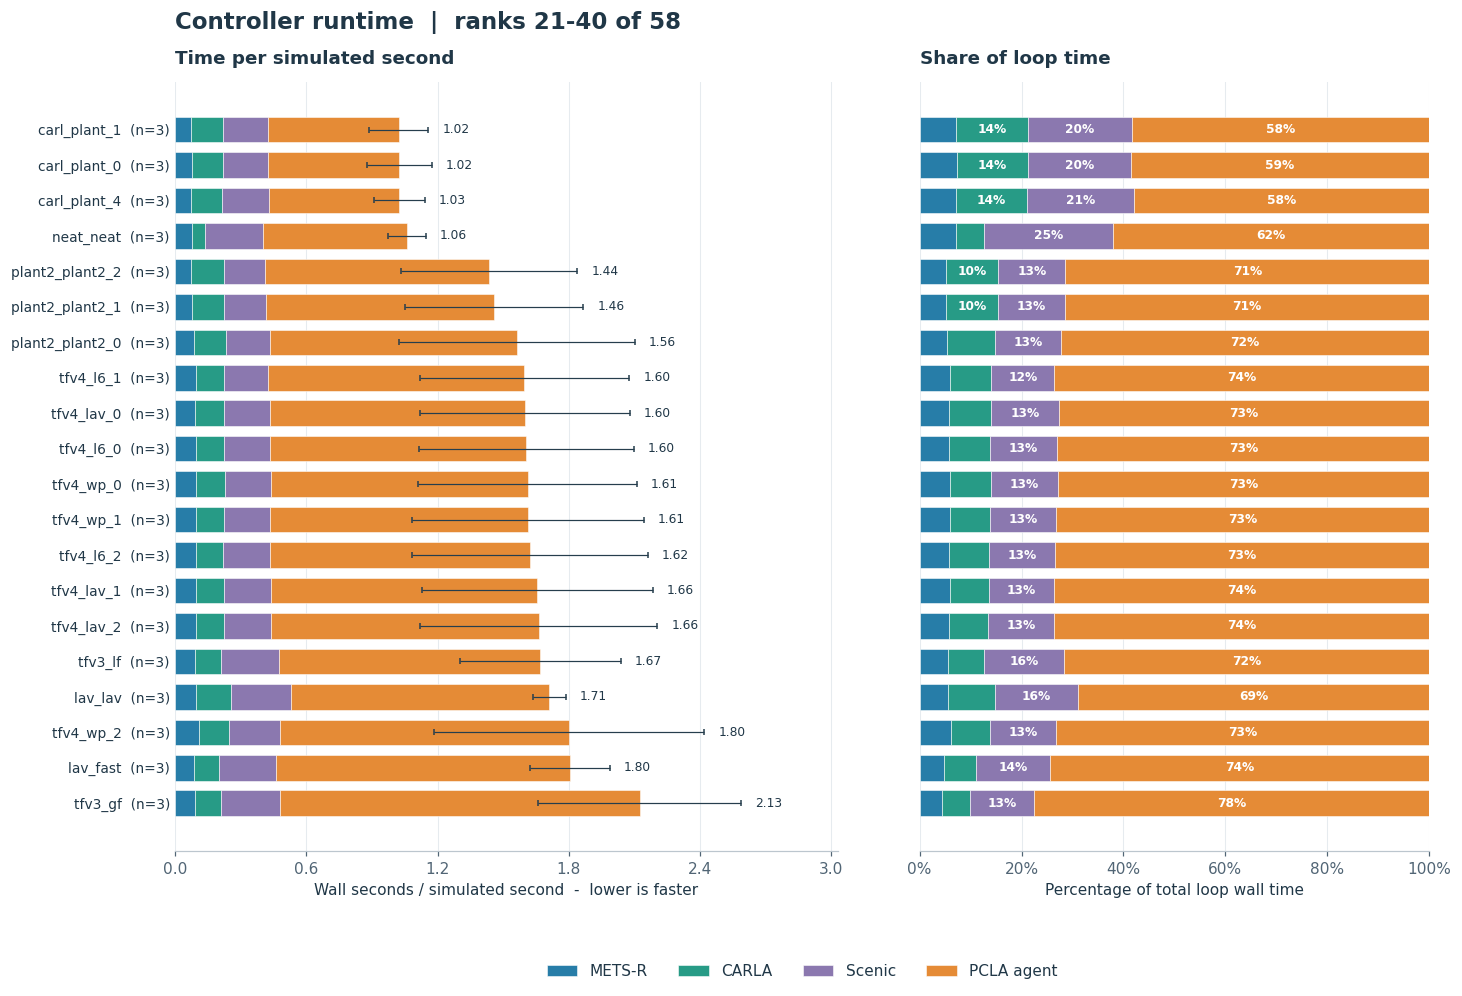

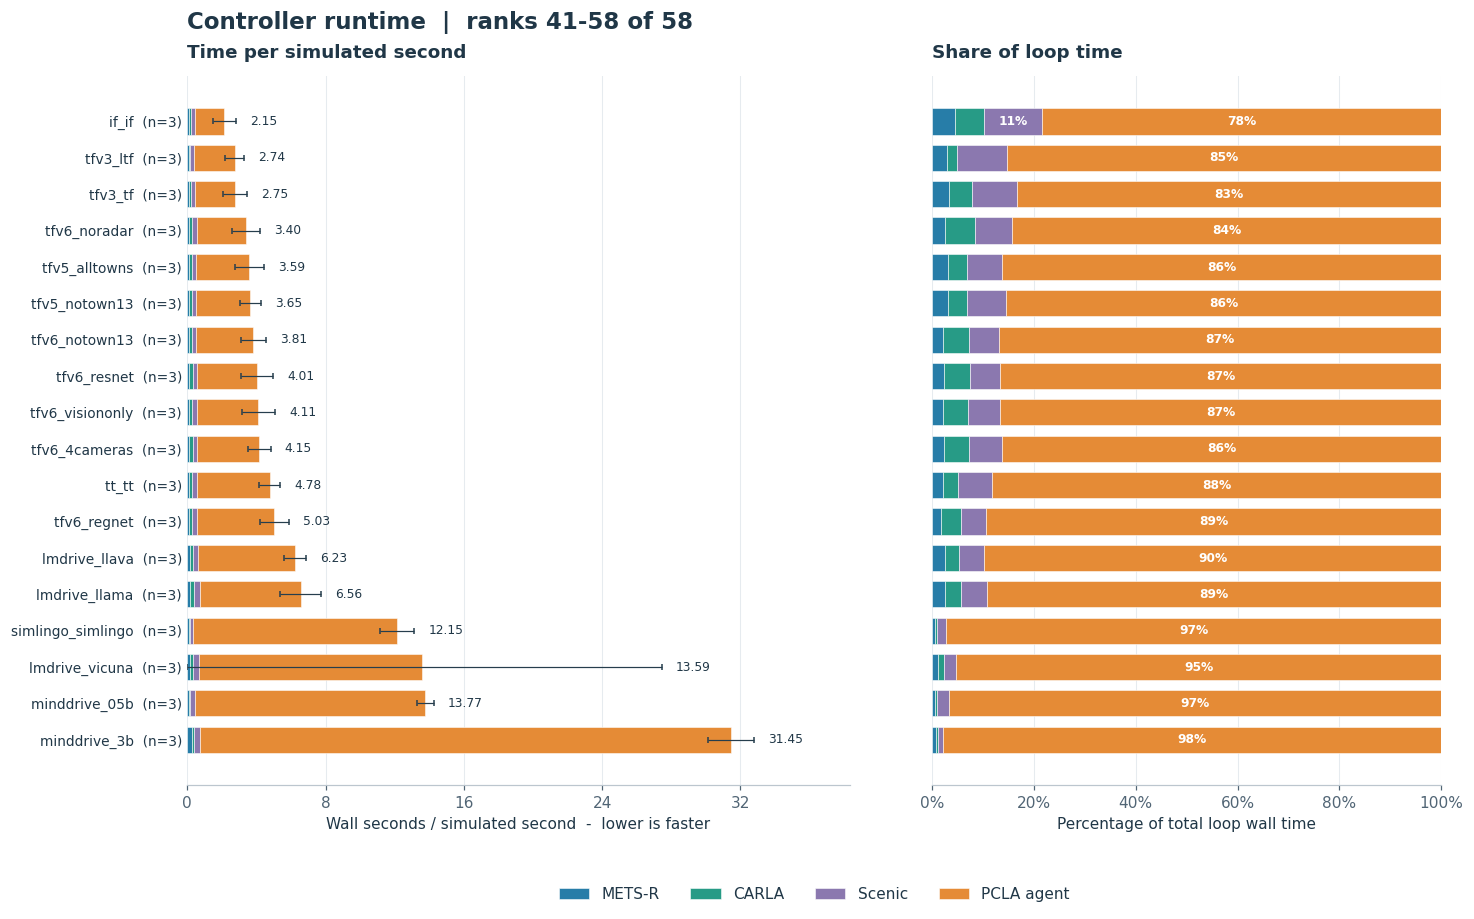

In [5]:
if not isinstance(CONTROLLERS_PER_FIGURE, int) or CONTROLLERS_PER_FIGURE < 1:
    raise ValueError("CONTROLLERS_PER_FIGURE must be a positive integer.")
exported_figures = []
def finish_figure(fig, stem):
    if SAVE_OUTPUTS:
        output_dir.mkdir(parents=True, exist_ok=True)
        for extension in ("png", "pdf"):
            path = output_dir / f"{stem}.{extension}"
            fig.savefig(path, bbox_inches="tight", facecolor="white")
            exported_figures.append(path)
    plt.show()
    plt.close(fig)

order = summary.index.tolist()
for start in range(0, len(order), CONTROLLERS_PER_FIGURE):
    names = order[start:start + CONTROLLERS_PER_FIGURE]
    costs = normalized_costs.loc[names]
    percentages = shares.loc[names]
    totals = costs.sum(axis=1).to_numpy()
    std = summary.loc[names, "normal_cost_std"].fillna(0).to_numpy()
    y = np.arange(len(names))
    fig, (ax, pct) = plt.subplots(1, 2, figsize=(15, max(3.8, len(names) * 0.36 + 2)),
                                  sharey=True, gridspec_kw={"width_ratios": [1.3, 1]})
    left, percent_left = np.zeros(len(names)), np.zeros(len(names))
    for name, (label, color) in COSTS.items():
        values = costs[name].to_numpy()
        pct_values = percentages[name].to_numpy()
        ax.barh(y, values, left=left, color=color, height=0.72, edgecolor="white", linewidth=0.35, label=label)
        pct.barh(y, pct_values, left=percent_left, color=color, height=0.72, edgecolor="white", linewidth=0.35)
        for row, value in enumerate(pct_values):
            if value >= 10:
                pct.text(percent_left[row] + value / 2, row, f"{value:.0f}%", ha="center", va="center",
                         fontsize=8, color="white", weight="bold")
        left += values
        percent_left += pct_values
    ax.errorbar(totals, y, xerr=np.vstack([np.minimum(std, totals), std]), fmt="none",
                ecolor="#263E4D", elinewidth=0.8, capsize=2)
    extent = float(np.max(totals + std))
    for row, total in enumerate(totals):
        ax.text(total + std[row] + extent * 0.025, row, f"{total:.2f}", va="center", fontsize=8)
    ax.set_xlim(0, extent * 1.17)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{name}  (n={int(summary.loc[name, 'n_runs'])})" for name in names], fontsize=9)
    ax.invert_yaxis()
    ax.set_title("Time per simulated second", loc="left", pad=12, weight="bold")
    ax.set_xlabel("Wall seconds / simulated second  -  lower is faster")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    pct.set_title("Share of loop time", loc="left", pad=12, weight="bold")
    pct.set_xlim(0, 100)
    pct.xaxis.set_major_formatter(PercentFormatter(100))
    pct.set_xlabel("Percentage of total loop wall time")
    pct.tick_params(axis="y", labelleft=False)
    for panel in (ax, pct):
        panel.set_axisbelow(True)
        panel.grid(axis="x", color="#E6EBEF", linewidth=0.7)
        panel.tick_params(axis="y", length=0)
        panel.spines["left"].set_visible(False)
    fig.suptitle(f"Controller runtime  |  ranks {start + 1}-{start + len(names)} of {len(order)}",
                 fontsize=15, weight="bold", x=0.22, ha="left")
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.6, 0.01))
    fig.subplots_adjust(left=0.22, right=0.98, top=0.91, bottom=0.15, wspace=0.14)
    finish_figure(fig, f"runtime_stack_{start // CONTROLLERS_PER_FIGURE + 1:02d}")


## 5. PCLA initialization versus actions

A large PCLA share can come from loading the model, from recurring actions, or both. This separate chart shows **mean inclusive PCLA initialization and action time per run** for the slowest controllers. Initialization includes route/sensor setup and nested CARLA calls. Action time includes preprocessing and sensor waits as well as model execution; it is not pure neural-network inference time.

These two detail measurements overlap with categories in the four-part stack above, so they are shown separately. Every repetition constructs a fresh controller. Omitting the first repetition does not yield a measurement with initialization removed.


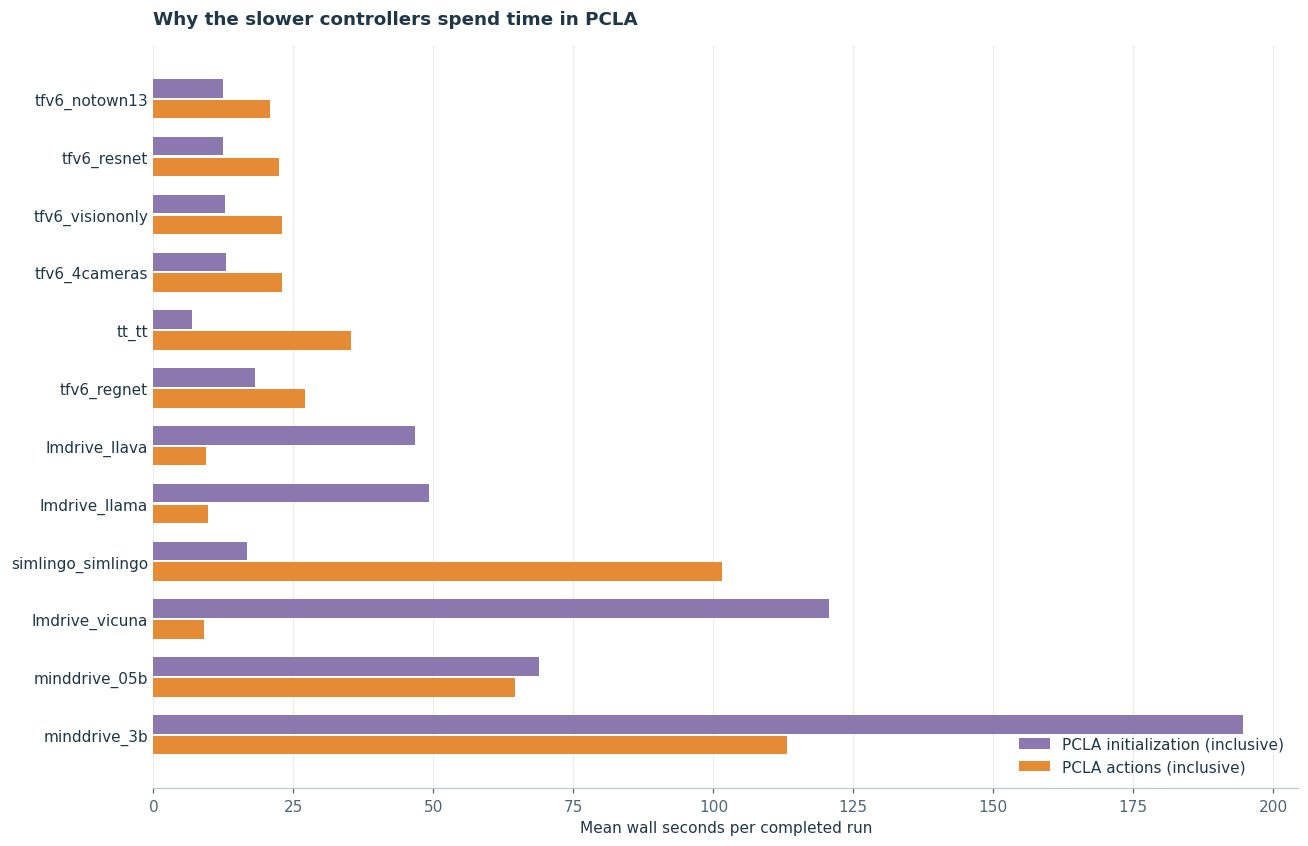

,n_runs,pcla_setup_mean_s,pcla_action_mean_s,pcla_action_mean_ms
agent,,,,
tfv6_notown13,3,12.46,20.78,207.80
tfv6_resnet,3,12.40,22.50,225.02
tfv6_visiononly,3,12.84,22.93,229.31
tfv6_4cameras,3,13.00,22.95,229.47
tt_tt,3,6.97,35.33,353.27
tfv6_regnet,3,18.05,27.06,270.62
lmdrive_llava,3,46.66,9.38,93.78
lmdrive_llama,3,49.21,9.75,97.54
simlingo_simlingo,3,16.71,101.44,1014.45


In [6]:
if not isinstance(PCLA_DETAIL_COUNT, int) or PCLA_DETAIL_COUNT < 1:
    raise ValueError("PCLA_DETAIL_COUNT must be a positive integer.")
detail = summary.tail(PCLA_DETAIL_COUNT).dropna(subset=["pcla_setup_mean_s", "pcla_action_mean_s"])
if detail.empty:
    print("No PCLA initialization/action detail was recorded in the selected CSVs.")
else:
    y = np.arange(len(detail))
    fig, ax = plt.subplots(figsize=(12, max(4, len(detail) * 0.5 + 1.8)))
    ax.barh(y - 0.18, detail.pcla_setup_mean_s, height=0.32, color="#8B78AF", label="PCLA initialization (inclusive)")
    ax.barh(y + 0.18, detail.pcla_action_mean_s, height=0.32, color="#E58B36", label="PCLA actions (inclusive)")
    ax.set_yticks(y)
    ax.set_yticklabels(detail.index)
    ax.invert_yaxis()
    ax.set_xlabel("Mean wall seconds per completed run")
    ax.set_title("Why the slower controllers spend time in PCLA", loc="left", pad=14, weight="bold")
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#E6EBEF", linewidth=0.7)
    ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_visible(False)
    ax.legend(loc="lower right", frameon=False)
    fig.tight_layout()
    finish_figure(fig, "pcla_initialization_and_actions")
    display(detail[["n_runs", "pcla_setup_mean_s", "pcla_action_mean_s", "pcla_action_mean_ms"]].round(2))


## 6. Findings and reusable outputs

The findings below are calculated from the selected data. Rankings describe this experiment's scenario, duration, seeds, cache state, and machine. Controller actions can change traffic trajectories and bubble contents even under matching seeds. The bars describe observed runtime rather than driving quality.


In [7]:
fastest, slowest = summary.index[0], summary.index[-1]
ratio = summary.loc[slowest, "wall_s_per_sim_s"] / summary.loc[fastest, "wall_s_per_sim_s"]
dominant_counts = summary.dominant_component.value_counts()
findings = [
    f"**{len(summary)} controllers** compared across **{len(valid)} valid completed runs** from `{session_dir.name}`.",
    f"Lowest measured loop cost: **{fastest}**, {summary.loc[fastest, 'wall_s_per_sim_s']:.2f} wall s / simulated s "
    f"({summary.loc[fastest, 'loop_mean_s']:.2f} s per run; {summary.loc[fastest, 'realtime_factor']:.2f}x real time).",
    f"Highest measured loop cost: **{slowest}**, {summary.loc[slowest, 'wall_s_per_sim_s']:.2f} wall s / simulated s "
    f"({ratio:.1f}x the lowest cost in this selection).",
    "Largest runtime component by controller: " + ", ".join(f"**{name}** in {int(count)}" for name, count in dominant_counts.items()) + ".",
]
not_plotted = coverage.index[coverage.plotted_runs.eq(0)].tolist()
if not_plotted:
    findings.append("No valid completed runs plotted for: " + ", ".join(f"`{name}`" for name in not_plotted) + ".")
if len(valid) == len(summary):
    findings.append("Only one repetition per controller is available; between-run variability cannot be estimated.")
display(Markdown("\n".join("- " + item for item in findings)))

if SAVE_OUTPUTS:
    output_dir.mkdir(parents=True, exist_ok=True)
    summary.to_csv(output_dir / "controller_summary.csv", index_label="agent")
    coverage.to_csv(output_dir / "controller_coverage.csv", index_label="agent")
    valid.to_csv(output_dir / "analyzed_runs.csv", index=False)
    source_manifest = {
        "session": session_dir.name, "source_directory": str(session_dir),
        "generated_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "match_repetitions": MATCH_REPETITIONS, "excluded_runs": EXCLUDE_RUNS,
        "agent_filter": AGENTS, "cohort_filter": COHORT_FILTER,
        "analyzed_controllers": len(summary), "analyzed_runs": len(valid),
        "load_issues": load_issues,
        "csv_files": [{"name": path.name, "size_bytes": path.stat().st_size,
                       "modified_ns": path.stat().st_mtime_ns} for path in csv_paths],
        "metric": "sum(component wall seconds) / sum(simulated seconds)",
    }
    (output_dir / "analysis_manifest.json").write_text(json.dumps(source_manifest, indent=2), encoding="utf-8")
    (output_dir / "findings.md").write_text("\n".join("- " + item for item in findings) + "\n", encoding="utf-8")
    print(f"Saved {len(exported_figures)} figure files and analysis tables to {output_dir}")


- **58 controllers** compared across **174 valid completed runs** from `20260913_174359_1789335839086850722`.
- Lowest measured loop cost: **lbc_lb**, 0.62 wall s / simulated s (6.20 s per run; 1.61x real time).
- Highest measured loop cost: **minddrive_3b**, 31.45 wall s / simulated s (50.7x the lowest cost in this selection).
- Largest runtime component by controller: **PCLA agent** in 57, **Scenic** in 1.
- No valid completed runs plotted for: `orion_base`.

Saved 8 figure files and analysis tables to /mnt/c/Users/ALei/Documents/GitHub/METS-R_HPC/output/demo2_analysis/20260913_174359_1789335839086850722
